# Optional Lab - Neurons and Layers

In this lab we will explore the inner working of neurons/units and layers. In particular, the lab will draw parallels to the models you have mastered in Course 1, the regression/linear model and the logistic model. The lab will introduce TensorFlow and demonstrate how these models are implemented in that framework.

<div style="display:flex;">
  <img src="../../images/C2_W1_NeuronsAndLayers.png" width="100%">
</div>



---

## Packages

### Tensorflow and Keras

Tensorflow is a machine learning package developed by Google. In 2019, Google integrated Keras into Tensorflow 2.0. Keras is a framework developed independently by Francois Chollet that creates a simple, layer-centric interface to Tensorflow. This course will be using the Keras interface.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input 
from tensorflow.keras import Sequential
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy
from tensorflow.keras.activations import sigmoid
from lab_utils_common import dlc
from lab_neurons_utils import plt_prob_1d, sigmoidnp, plt_linear, plt_logistic

plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

---

## Neuron without activation - Regression/Linear Model

### Dataset
We will use an example from Course 1, linear regression house prices

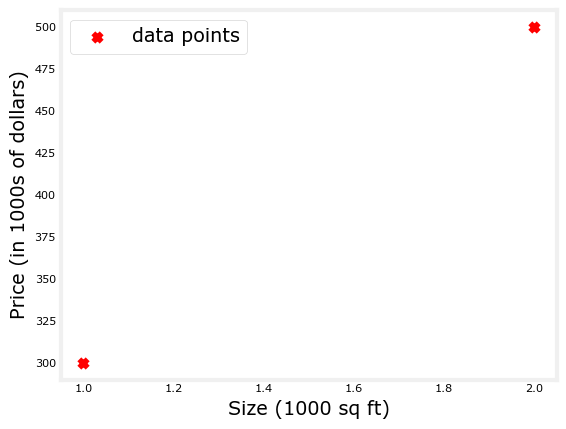

In [5]:
x_train = np.array([[1.0], [2.0]], dtype=np.float32)
y_train = np.array([[300.0], [500.0]], dtype=np.float32)

fig, ax = plt.subplots(1,1)
ax.scatter(x_train, y_train, marker='x', c='r', label='data points')
ax.legend(fontsize='xx-large')
ax.set_ylabel('Price (in 1000s of dollars)', fontsize='xx-large')
ax.set_xlabel('Size (1000 sq ft)', fontsize='xx-large')
plt.show()

### Regression/Linear Model

The function implemented by a neuron with no activation is the same as in Course 1, linear regression

$$
f_{\mathbf{w},b}(x^{(i)}) = \mathbf{w}\cdot x^{(i)} + b \tag{1}
$$

> We can define a layer with one neuron or unit and compare it to the familiar linear regression function.
> Then we examine the weights.

In [6]:
# Define a layer with a single neuron
linear_layer = tf.keras.layers.Dense(units=1, activation='linear')
# Examine the weights
linear_layer.get_weights()

[]

As we can see there is no weights because we have not instantiated it yet. Let's try the model on one example in `x_train`. This will trigger the instantiation of the weights. Note that the input to the later must be 2-D, so we have to reshape it.

In [7]:
a1 = linear_layer(x_train[0].reshape(1,1))
print(a1)

tf.Tensor([[1.3547505]], shape=(1, 1), dtype=float32)


The result is a tensor (another name for an array) with a shape of (1,1) or one entry.   
Now let's look at the weights and bias. These weights are randomly initialized to small numbers and the bias defaults to being initialized to zero.

In [8]:
w,b = linear_layer.get_weights()
print(f"Weight: {w}, Bias: {b}")

Weight: [[1.3547505]], Bias: [0.]


A linear regression model (1) with a single input feature will have a single weight and bias. This matches the dimensions of our `linear_layer` above.   

The weights are initialized to random values so let's set them to some known values.

In [11]:
set_w = np.array([[200.0]])
set_b = np.array([100.0])

# set_weights() takes a list of numpy arrays
linear_layer.set_weights([set_w, set_b])
print(f"Weight: {linear_layer.get_weights()}")

Weight: [array([[200.]], dtype=float32), array([100.], dtype=float32)]


Let's compare equation (1) to the layer output.

In [12]:
a1 = linear_layer(x_train[0].reshape(1,1))
print(a1)
alin = np.dot(set_w, x_train[0].reshape(1,1)) + set_b
print(alin)

tf.Tensor([[300.]], shape=(1, 1), dtype=float32)
[[300.]]


They produce the same values!
Now, we can use our linear layer to make predictions on our training data.

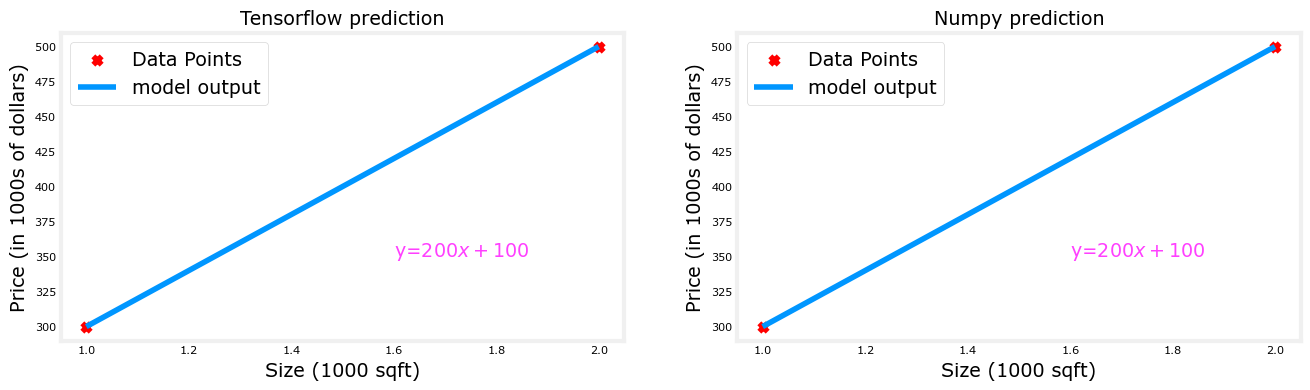

In [13]:
pred_tf = linear_layer(x_train)
pred_np = np.dot(x_train, set_w) + set_b
plt_linear(x_train, y_train, pred_tf, pred_np)

---

## Neuron with Sigmoid activation

The function implemented by a neuron/unit with a sigmoid activation is the same as in Course 1, logistic regression:

$$
  f_{\mathbf{w},b}(x^{(i)}) = g(\mathbf{w}x^{(i)} + b) \tag{2}
$$

where

$$
  g(x) = sigmoid(x)
$$

Let's set $w$ and $b$ to some known values and check the model

### Dataset

In [14]:
x_train = np.array([0., 1, 2, 3, 4, 5], dtype=np.float32).reshape(-1,1) # 2-D matrix
y_train = np.array([0 , 0, 0, 1, 1, 1], dtype=np.float32).reshape(-1,1) # 2-D matrix

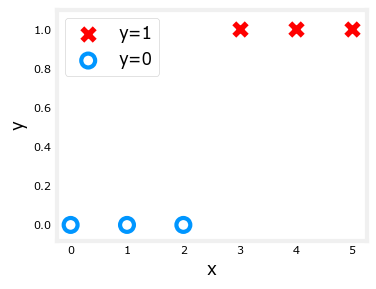

In [15]:
pos = y_train == 1
neg = y_train == 0

fig, ax = plt.subplots(1, 1, figsize=(4,3))
ax.scatter(x_train[pos], y_train[pos], marker='x', s=80, c='red', label='y=1')
ax.scatter(x_train[neg], y_train[neg], marker='o', s=100, label='y=0', facecolors='none', edgecolors=dlc['dlblue'], lw=3)
ax.set_ylim(-0.08, 1.1)
ax.set_ylabel('y', fontsize='12')
ax.set_xlabel('x', fontsize='12')
ax.legend(fontsize=12)
plt.show()  

### Logistic Neuron

We can implement a 'logistic neuron' by adding a sigmoid activation. The function of the neuron is then described by (2) above.

This section will create a Tensorflow Model that contains our logistic layer to demonstrate an alternate method of creating models. Tensorflow is most often used to create multi-layer models. The [Sequential](https://keras.io/guides/sequential_model/) model is a convenient means of constructing these models.

`model.summary()` shows the layers and number of parameters in the models. There is only one layer in this model and that layer has only one unit. The unit has two parameters, $w$ and $b$

In [18]:
model = Sequential([
  tf.keras.layers.Dense(
    1,
    input_dim=1,
    activation='sigmoid',
    name='L1'
  )
])

model.summary()
logistic_layer = model.get_layer('L1')
w,b = logistic_layer.get_weights()

print(f"Weight: {w}, Bias: {b}")
print(f"w.shape: {w.shape}, b.shape: {b.shape}")

e:\Codebases\jupyter_stash\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Weight: [[-0.722101]], Bias: [0.]
w.shape: (1, 1), b.shape: (1,)


Let's set the weight and bias to some known values. Then compare equation (2) to the layer output.

In [19]:
set_w = np.array([[2]])
set_b = np.array([-4.5])

# set_weights() takes a list of numpy arrays
logistic_layer.set_weights([set_w, set_b])
print(logistic_layer.get_weights())

a1 = model.predict(x_train[0].reshape(1,1))
print(a1)
alog = sigmoidnp(np.dot(set_w, x_train[0].reshape(1,1)) + set_b)
print(alog)


[array([[2.]], dtype=float32), array([-4.5], dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
[[0.01098694]]
[[0.01098694]]


They produce the same values!
Now, we can use our logistic layer and NumPy model to make predictions on our training data.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

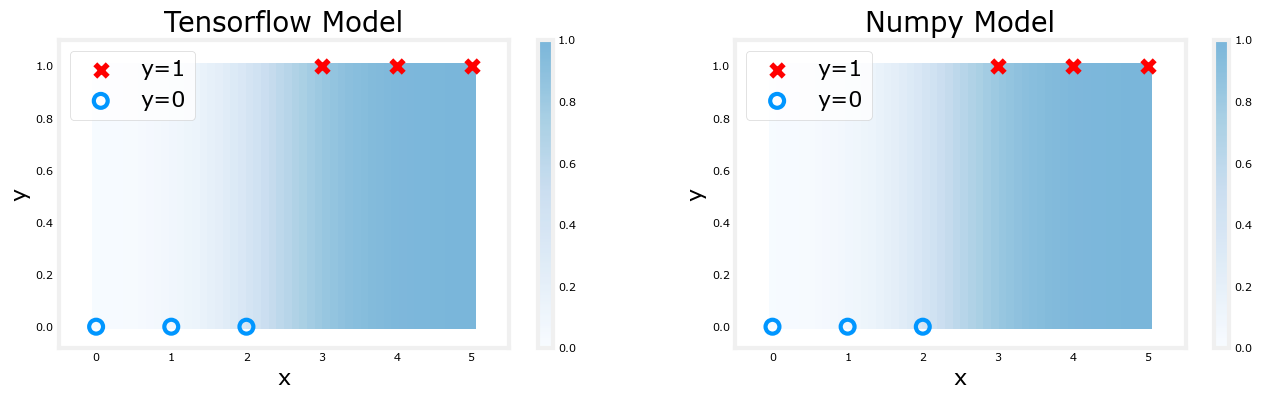

In [20]:
plt_logistic(x_train, y_train, model, set_w, set_b, pos, neg)

The shading above reflects the output of the sigmoid which varies from 0 to 1.